In [2]:
import pandas as pd
import numpy as np
import seaborn as sb
import matplotlib.pyplot as plt

In [3]:
import warnings
warnings.filterwarnings("ignore")

In [4]:
df = pd.read_csv("train.csv")

In [5]:
df.head()
# print(pr)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [7]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


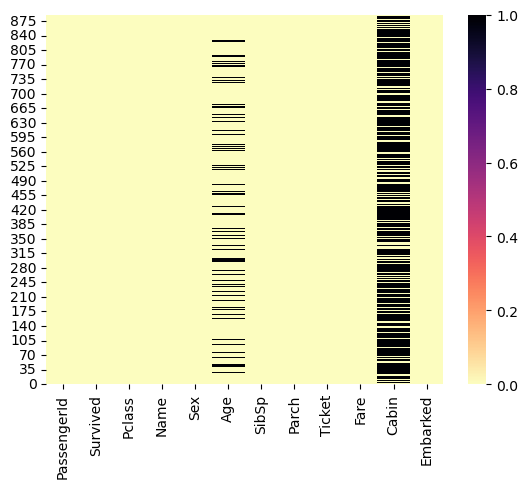

In [8]:
sb.heatmap(df.isnull(), cmap = 'magma_r')
# sb.heatmap(df.isnull(), cmap=sb.color_palette("magma", as_cmap=True).reversed())
plt.gca().invert_yaxis() # flips the y-axis plt.show()

In [9]:
cabin_list = [ 'A', 'B', 'C', 'D', 'E', 'F', 'T', 'G', 'Unknown' ]

In [10]:
def search_substring(big_string, substring_list):
    for substring in substring_list:
        if substring in big_string:
            return substring
    return substring_list[-1]   # return last element if none found

In [11]:
def get_title(string): # function get_title and it has a parameter string, that string contains passenger name
    import re #regular expression module is used for pattern matching or also known as regex library
    reg = re.compile(r'Mr|Don|Major|Capt|Jonkheer|Rev|Col|Dr|Mrs|Countess|Dona|Mme|Ms|Miss|Mile|Master', re.IGNORECASE) #it ignore upper or lower, 
    # it provide it original form
    results = reg.search(string)
    if results != None:
        return (results.group().lower()) #lower() it will take it as smaller
    else:
        return(str(np.nan))

In [12]:
get_title("Braund, Mr. Owen Harris") # regex will take all value and match it with any titles

'mr'

In [13]:
# dictionary to map to generate the new feature vector
title_dictionary = {
"capt":"Officer",
"col":"Officer",
"major":"Officer",
"dr":"Officer",
"jonkheer":"Royalty",
"rev":"Officer",
"countess":"Royalty",
"dona":"Royalty",
"lady":"Royalty",
"don":"Royalty",
"mr":"Mr",
"mme":"Mrs",
"ms":"Mrs",
"mrs":"Mrs",
"miss":"Miss",
"mlle":"Miss",
"master":"Master",
"nan":"Mr"
}

In [14]:
df['Deck'] = df['Cabin'].map(lambda x: search_substring(str(x), cabin_list))

In [15]:
print(df.columns)

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked', 'Deck'],
      dtype='object')


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
 12  Deck         891 non-null    object 
dtypes: float64(2), int64(5), object(6)
memory usage: 90.6+ KB


In [17]:
df.drop(columns=['Cabin'], inplace=True, errors='ignore')

In [18]:
df['Title'] = df['Name'].apply(get_title)

In [19]:
df['Title'] = df['Title'].map(title_dictionary)

In [20]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Deck,Title
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,Unknown,Mr
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,C,Mr
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,Unknown,Miss
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,C,Mr
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,Unknown,Mr


In [21]:
df.drop('Name',axis=1,inplace= True)


In [22]:
df.tail()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Deck,Title
886,887,0,2,male,27.0,0,0,211536,13.00,S,Unknown,Officer
887,888,1,1,female,19.0,0,0,112053,30.00,S,B,Miss
888,889,0,3,female,NaN,1,2,W./C. 6607,23.45,S,Unknown,Miss
889,890,1,1,male,26.0,0,0,111369,30.00,C,C,Mr
890,891,0,3,male,32.0,0,0,370376,7.75,Q,Unknown,Mr


In [23]:
df.drop('Ticket', axis =1 , inplace =True)

In [24]:
df.tail()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Deck,Title
886,887,0,2,male,27.0,0,0,13.00,S,Unknown,Officer
887,888,1,1,female,19.0,0,0,30.00,S,B,Miss
888,889,0,3,female,NaN,1,2,23.45,S,Unknown,Miss
889,890,1,1,male,26.0,0,0,30.00,C,C,Mr
890,891,0,3,male,32.0,0,0,7.75,Q,Unknown,Mr


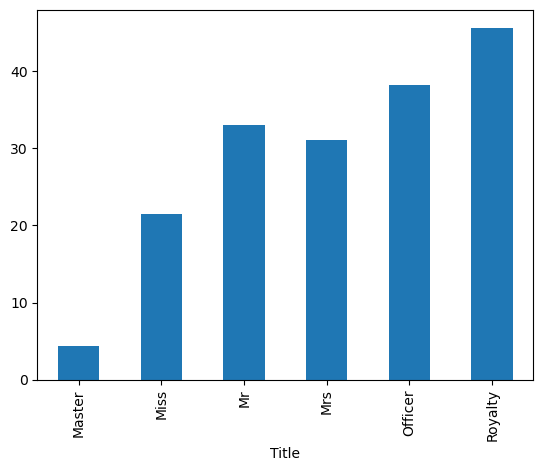

In [25]:
means_title = df.groupby('Title')['Age'].mean()
mk = df.groupby('Title')['Age'].mean().plot(kind='bar')

In [26]:
title_list = ['Mr','Miss','Mrs','Master','Royalty','Officer']

def age_nan_replace(means, dframe, title_list):
    for title in title_list:
        temp = dframe['Title'] == title
        dframe.loc[temp, 'Age'] = dframe.loc[temp, 'Age'].fillna(means[title])

age_nan_replace(means_title, df, title_list)


<Axes: >

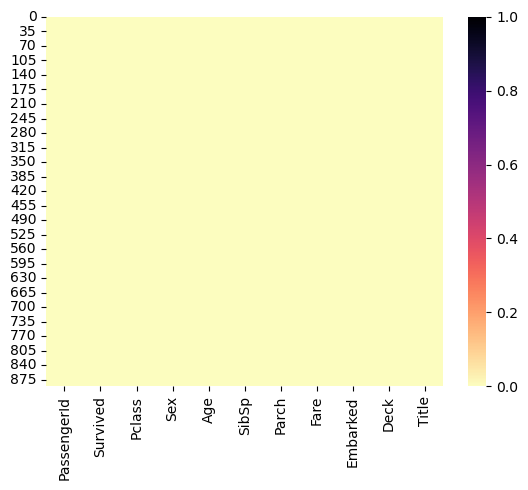

In [27]:
sb.heatmap(df.isnull(), cmap='magma_r')

<Axes: xlabel='Embarked'>

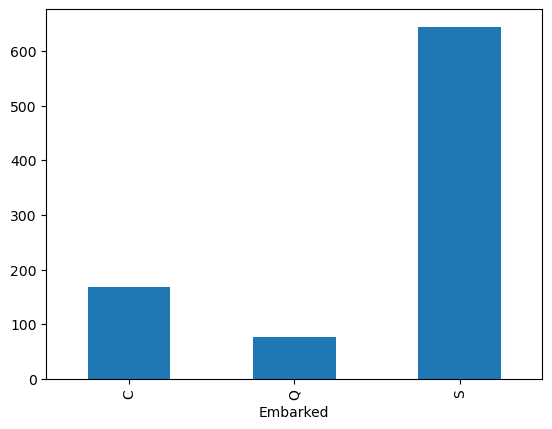

In [28]:
df.groupby('Embarked').size().plot(kind='bar')

In [29]:
df['Embarked'].fillna('S', inplace=True)
df.head()
                      

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Deck,Title
0,1,0,3,male,22.0,1,0,7.2500,S,Unknown,Mr
1,2,1,1,female,38.0,1,0,71.2833,C,C,Mr
2,3,1,3,female,26.0,0,0,7.9250,S,Unknown,Miss
3,4,1,1,female,35.0,1,0,53.1000,S,C,Mr
4,5,0,3,male,35.0,0,0,8.0500,S,Unknown,Mr


<Axes: xlabel='Parch'>

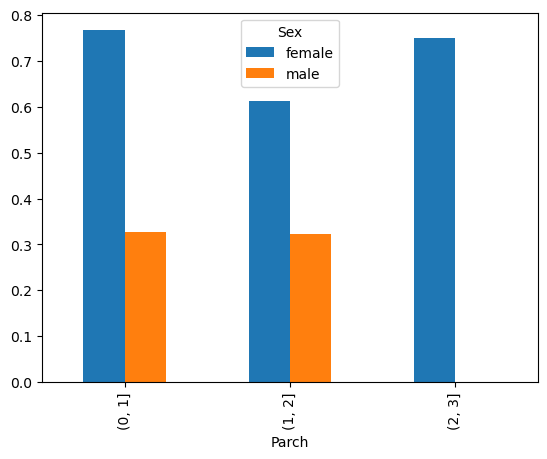

In [30]:
parch_intervals = pd.cut(df['Parch'], [0,1,2,3])
df.pivot_table('Survived', parch_intervals, 'Sex').plot(kind='bar')

<Axes: xlabel='SibSp'>

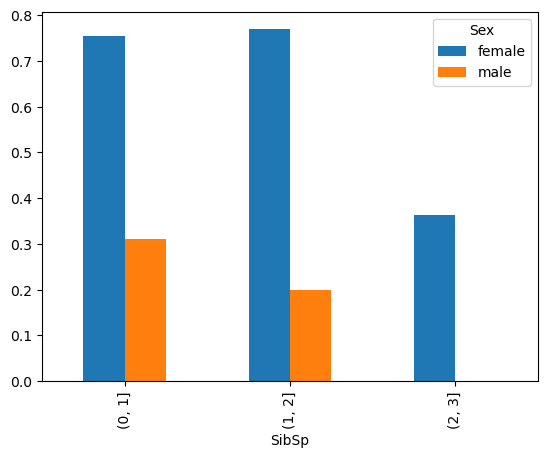

In [31]:
parch_intervals = pd.cut(df['SibSp'], [0,1,2,3])
df.pivot_table('Survived', parch_intervals, 'Sex').plot(kind='bar')

In [32]:
df['Family Size'] = df['Parch'] + df['SibSp']
df.drop('Parch',axis =1 , inplace = True)
df.drop('SibSp',axis =1 , inplace = True)
df.head()

,PassengerId,Survived,Pclass,Sex,Age,Fare,Embarked,Deck,Title,Family Size
0,1,0,3,male,22.0,7.2500,S,Unknown,Mr,1
1,2,1,1,female,38.0,71.2833,C,C,Mr,1
2,3,1,3,female,26.0,7.9250,S,Unknown,Miss,0
3,4,1,1,female,35.0,53.1000,S,C,Mr,1
4,5,0,3,male,35.0,8.0500,S,Unknown,Mr,0


In [33]:
df.head()

,PassengerId,Survived,Pclass,Sex,Age,Fare,Embarked,Deck,Title,Family Size
0,1,0,3,male,22.0,7.2500,S,Unknown,Mr,1
1,2,1,1,female,38.0,71.2833,C,C,Mr,1
2,3,1,3,female,26.0,7.9250,S,Unknown,Miss,0
3,4,1,1,female,35.0,53.1000,S,C,Mr,1
4,5,0,3,male,35.0,8.0500,S,Unknown,Mr,0
